# Backtest Results

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from pairs_teardown.data.loaders import load_or_download
from pairs_teardown.data.clean import handle_missing, align_prices, to_log_prices
from pairs_teardown.signals.spread import build_rolling_spread, rolling_zscore, rolling_hedge_ratio
from pairs_teardown.signals.rules import target_positions
from pairs_teardown.backtest.costs import CostModel
from pairs_teardown.backtest.engine import run_backtest
from pairs_teardown.stats.cointegration import estimate_hedge_ratio

ALL_TICKERS = ["WM", "RSG", "FOXA", "FOX", "SPY", "VOO"]
prices_raw = load_or_download(
    ALL_TICKERS, "2015-01-01", "2024-12-31", cache_dir=Path("../data/raw")
)

pair_defs = [("WM", "RSG"), ("FOXA", "FOX"), ("SPY", "VOO")]
pairs = {
    f"{a}/{b}": align_prices(handle_missing(prices_raw[[a, b]]))
    for a, b in pair_defs
}

for name, df in pairs.items():
    print(f"{name}: {len(df)} days, {df.index[0].date()} → {df.index[-1].date()}")

Loading from cache: FOX_FOXA_RSG_SPY_VOO_WM_20150101_20241231.parquet
WM/RSG: 2515 days, 2015-01-02 → 2024-12-30
FOXA/FOX: 1461 days, 2019-03-13 → 2024-12-30
SPY/VOO: 2515 days, 2015-01-02 → 2024-12-30


In [2]:
WINDOW, ENTRY, EXIT = 60, 2.0, 0.5
costs = CostModel(commission_bps=1.0, slippage_bps=5.0)   # 6 bps per side

results = {}
for a, b in pair_defs:
    name = f"{a}/{b}"
    raw = pairs[name]
    lg = to_log_prices(raw)

    # Signal: rolling hedge ratio, responsive to drift (unchanged)
    z = rolling_zscore(build_rolling_spread(lg[a], lg[b], WINDOW), WINDOW)
    pos = target_positions(z, ENTRY, EXIT)

    # Sizing: STATIC hedge ratio, stable, no estimation-noise blowup
    static_hr_value = estimate_hedge_ratio(lg[a], lg[b])
    static_hr = pd.Series(static_hr_value, index=raw.index)

    results[name] = run_backtest(raw[a], raw[b], pos, static_hr, costs)

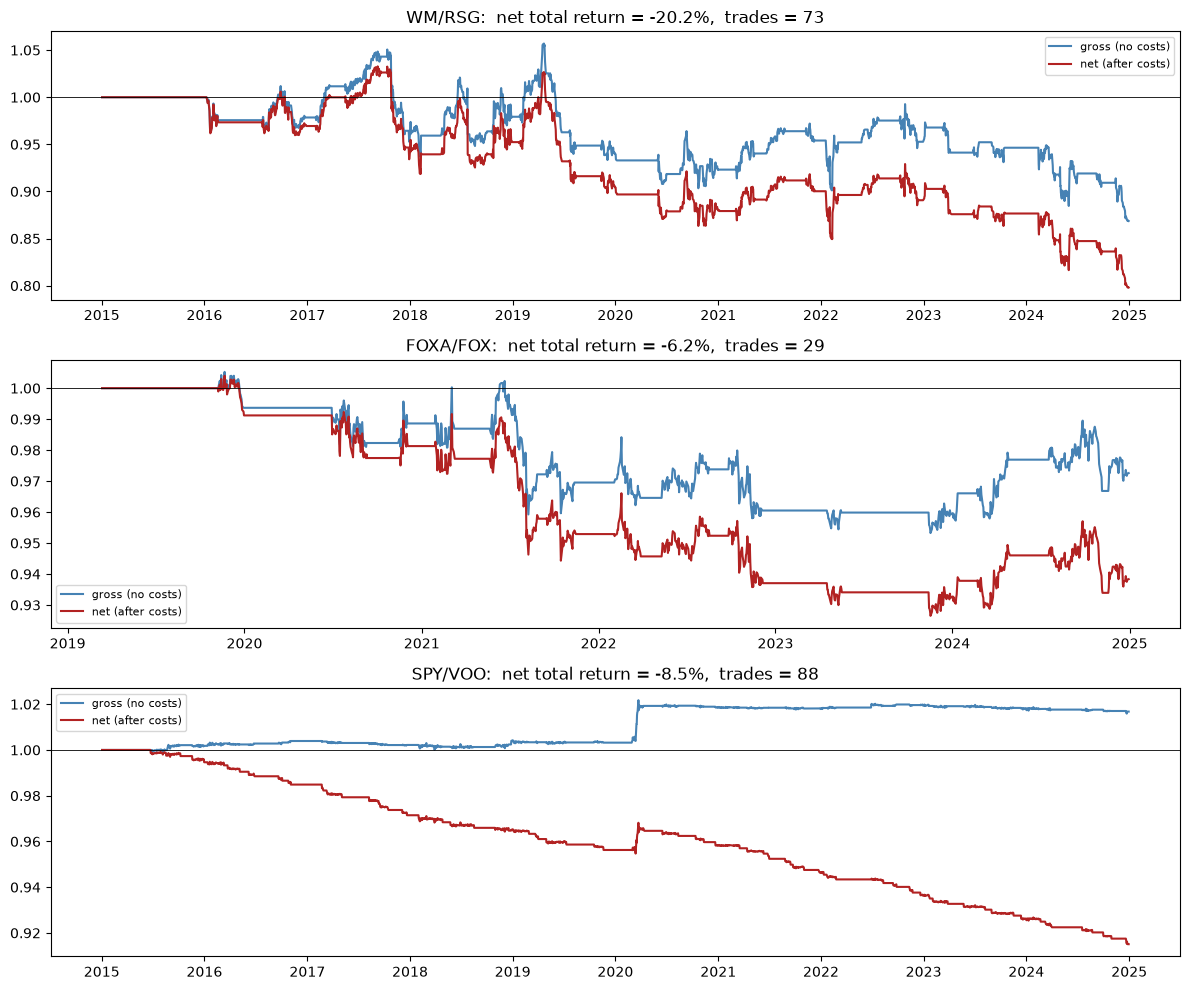

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for ax, (a, b) in zip(axes, pair_defs):
    name = f"{a}/{b}"
    res = results[name]
    idx = res.equity_curve.index
    ax.plot(idx, (1 + res.gross_returns).cumprod(), label="gross (no costs)", color="steelblue")
    ax.plot(idx, res.equity_curve, label="net (after costs)", color="firebrick")
    ax.axhline(1.0, color="black", lw=0.6)
    ax.set_title(f"{name}:  net total return = "
                 f"{(res.equity_curve.iloc[-1] - 1):.1%},  trades = {res.n_trades}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### SPY/VOO 2020 spike investigation

Gross return, COVID window only:  1.60%
Gross return, full sample:         1.68%
Gross return, full sample EXCLUDING COVID window:
  0.07%


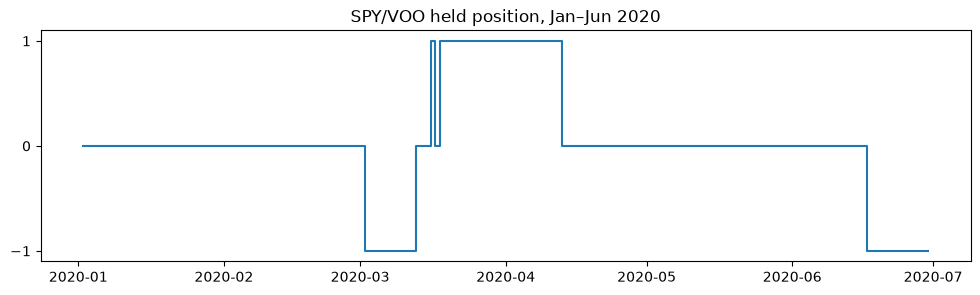

In [4]:
res = results["SPY/VOO"]

# Isolate the COVID window
covid_window = res.returns.loc["2020-02-01":"2020-04-30"]
full_sample = res.returns

print(f"Gross return, COVID window only:  {(1+res.gross_returns.loc['2020-02-01':'2020-04-30']).prod()-1:.2%}")
print(f"Gross return, full sample:         {(1+res.gross_returns).prod()-1:.2%}")
print(f"Gross return, full sample EXCLUDING COVID window:")
outside = res.gross_returns.drop(res.gross_returns.loc["2020-02-01":"2020-04-30"].index)
print(f"  {(1+outside).prod()-1:.2%}")

# Plot the position and z-score during that window to see what fired
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(res.held_positions.loc["2020-01-01":"2020-06-30"], drawstyle="steps-post")
ax.set_title("SPY/VOO held position, Jan–Jun 2020")
ax.set_yticks([-1, 0, 1])
plt.show()